# Наивный Байес

Наивный Байес — это простой вероятностный алгоритм классификации из области машинное обучение, основанный на теорема Байеса.

Он вычисляет вероятность того, что объект принадлежит к определённому классу, исходя из его признаков.

Метод предполагает, что все признаки независимы друг от друга (что редко бывает в реальности, но сильно упрощает расчёты, поэтому метод и называется "наивным").

# Используемые библиотеки

In [4]:
import pandas as pd
import numpy as np
import kagglehub
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.metrics import recall_score, f1_score, precision_score

# Описание и демонстрация датасета

Датасет представляет из себя данные пациентов. Цель модели - предсказывать пациентов, у которых диабет

In [5]:
# Скачивание и загрузка датасета
path_to_dataset = kagglehub.dataset_download("hassinarman/diabetes-bangladesh")
df = pd.read_csv(path_to_dataset + '/DiaBD_A Diabetes Dataset for Enhanced Risk Analysis and Research in Bangladesh.csv')

# Подготовка таргета и признаков
df['diabetic'] = df['diabetic'].map({'Yes': 1, 'No': 0})
y = df['diabetic']
X = df.drop(columns=['diabetic'])

print(f"Размер датасета: {df.shape}")
print("\nПервые 5 строк:")
display(X.head())
print("\nИнформация о типах данных:")
X.info()

100%|██████████| 73.2k/73.2k [00:00<00:00, 16.0MB/s]

Extracting files...
Размер датасета: (5288, 15)

Первые 5 строк:


,age,gender,pulse_rate,systolic_bp,diastolic_bp,glucose,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke
0,42,Female,66,110,73,5.88,1.65,70.2,25.75,0,0,0,0,0
1,35,Female,60,125,68,5.71,1.47,42.5,19.58,0,0,0,0,0
2,62,Female,57,127,74,6.85,1.52,47.0,20.24,0,0,0,0,0
3,73,Male,55,193,112,6.28,1.63,57.4,21.72,0,0,0,0,0
4,68,Female,71,150,81,5.71,1.42,36.0,17.79,0,0,0,0,0



Информация о типах данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5288 entries, 0 to 5287
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     5288 non-null   int64  
 1   gender                  5288 non-null   object 
 2   pulse_rate              5288 non-null   int64  
 3   systolic_bp             5288 non-null   int64  
 4   diastolic_bp            5288 non-null   int64  
 5   glucose                 5288 non-null   float64
 6   height                  5288 non-null   float64
 7   weight                  5288 non-null   float64
 8   bmi                     5288 non-null   float64
 9   family_diabetes         5288 non-null   int64  
 10  hypertensive            5288 non-null   int64  
 11  family_hypertension     5288 non-null   int64  
 12  cardiovascular_disease  5288 non-null   int64  
 13  stroke                  5288 non-null   int64  
dtypes: float64(4

# Препроцессинг датасета

In [6]:
# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.3)

# Кодирование категориальных признаков
NUM_COLUMNS = X_train.select_dtypes(include=np.number).columns.tolist()
CAT_COLUMNS = X_train.select_dtypes(include='object').columns.tolist()

ct = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), CAT_COLUMNS)],
    remainder='passthrough',
    verbose_feature_names_out=False
)

X_train_enc = ct.fit_transform(X_train)
X_test_enc = ct.transform(X_test)

# Преобразование в DataFrame для удобства
X_train = pd.DataFrame(X_train_enc, columns=ct.get_feature_names_out())
X_test = pd.DataFrame(X_test_enc, columns=ct.get_feature_names_out())
X_train = X_train.astype(float)
X_test = X_test.astype(float)

# Тепловая карта

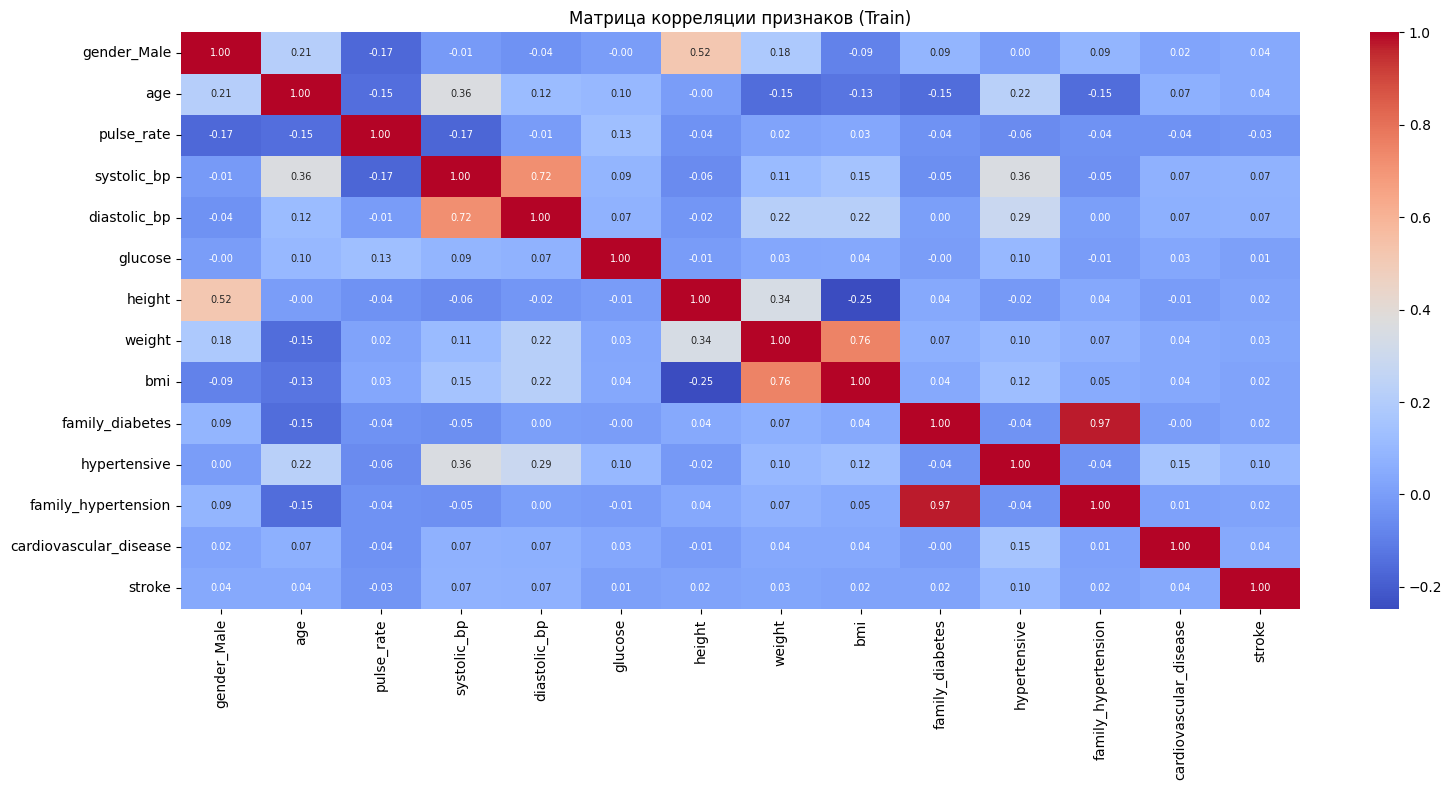

In [7]:
plt.figure(figsize=(16, 8))
sns.heatmap(X_train.corr(), annot=True, fmt=".2f", cmap='coolwarm', annot_kws={"size": 7})
plt.title("Матрица корреляции признаков (Train)")
plt.tight_layout()
plt.show()

# Обучение модели

In [8]:
# Инициализация и обучение Gaussian Naive Bayes

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

nb_model = GaussianNB()
nb_model.fit(X_train, y_train, sample_weight=sample_weights)

print("Модель успешно обучена.")
print(f"Точность на обучающей выборке: {nb_model.score(X_train, y_train):.4f}")

Модель успешно обучена.
Точность на обучающей выборке: 0.8665


# Тестирование модели

In [9]:
# Предсказания классов и вероятностей
y_pred = nb_model.predict(X_test)
y_proba = nb_model.predict_proba(X_test)[:, 1]

print("Отчёт по классификации:")
print(classification_report(y_test, y_pred, target_names=['Здоров (0)', 'Диабет (1)']))

Отчёт по классификации:
              precision    recall  f1-score   support

  Здоров (0)       0.97      0.86      0.91      1469
  Диабет (1)       0.28      0.68      0.40       118

    accuracy                           0.85      1587
   macro avg       0.63      0.77      0.66      1587
weighted avg       0.92      0.85      0.87      1587



# Визуализация результатов

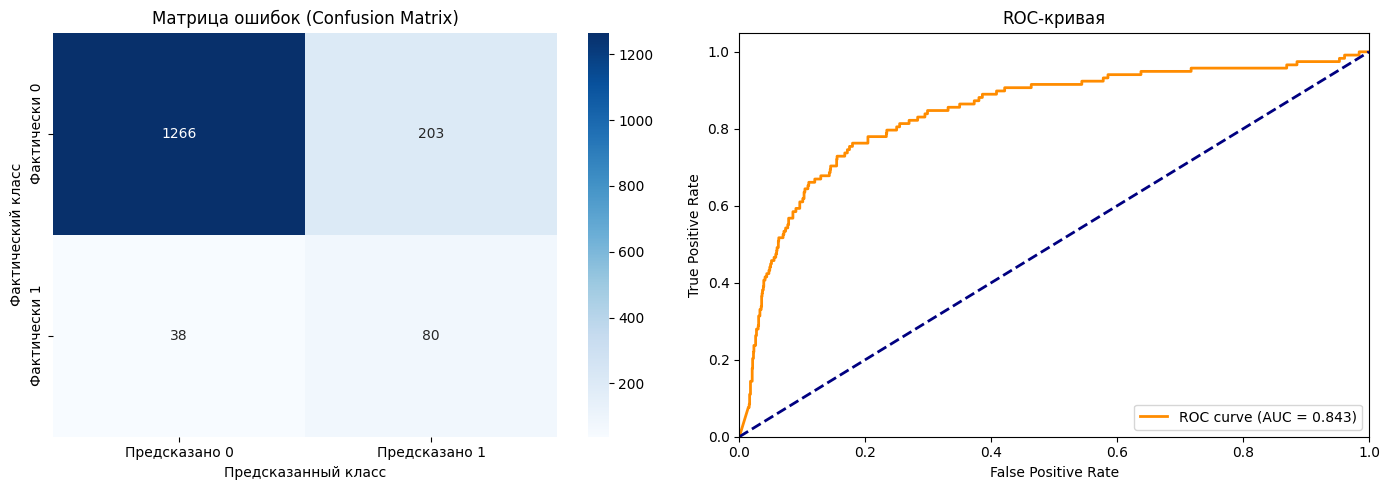

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Предсказано 0', 'Предсказано 1'],
            yticklabels=['Фактически 0', 'Фактически 1'])
axes[0].set_title('Матрица ошибок (Confusion Matrix)')
axes[0].set_ylabel('Фактический класс')
axes[0].set_xlabel('Предсказанный класс')

# 2. ROC-кривая
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC-кривая')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()